# 04 — Preliminary Before-and-After EDA: Albert Street

This notebook performs a **preliminary exploratory before-and-after comparison** for **Albert Street counter 9077** around the recorded intervention date of **4 June 2020**.

## Analysis approach

- Exact duplicate raw records are removed before daily aggregation.
- This cleaning decision is supported by the duplicate investigation and sensitivity analysis in Notebooks **02** and **03**.
- The original raw data are never overwritten.
- Only days with recorded observations are analysed.
- Missing dates are not filled, interpolated, or treated as zero.
- The intervention date itself is excluded.
- The intended study period is **1 January 2019 to 31 December 2022**.

## Known limitations

- A **168-day collection gap** occurs from **5 August 2019 to 19 January 2020** in the before-intervention period.
- A further **6-day gap** occurs from **26 December 2022 to 31 December 2022**.
- Seasonal patterns, COVID-19 disruptions, and other external factors may influence cycling volumes.
- This is preliminary EDA and should not be interpreted as proof that the intervention caused the observed change.

## 1. Import libraries and configure paths


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
import os
import yaml

def find_project_root(start=None):
    """Find the repository root by looking for .git or config.yaml."""
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() or (candidate / "config.yaml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()

config_path = PROJECT_ROOT / "config.yaml"
config = {}
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f) or {}

paths_cfg = config.get("paths", {})

RAW_ROOT = PROJECT_ROOT / paths_cfg.get("raw_dir", "data/raw")
PROCESSED_ROOT = PROJECT_ROOT / paths_cfg.get("processed_dir", "data/processed")

# Optional override for local machines:
# Windows PowerShell example:
#   $env:CYCLING_DATA_DIR="D:\\path\\to\\CYCLING_DATA"
CYCLING_DATA_DIR = Path(
    os.environ.get(
        "CYCLING_DATA_DIR",
        RAW_ROOT / "cycling_data"
    )
).expanduser().resolve()

CYCLING_PROCESSED_DIR = PROCESSED_ROOT / "cycling_counters"
CYCLING_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cycling raw data:", CYCLING_DATA_DIR)
print("Cycling processed data:", CYCLING_PROCESSED_DIR)

EXTRACTION_DIR = CYCLING_PROCESSED_DIR / "extraction"
OUTPUT_DIR = CYCLING_PROCESSED_DIR / "preliminary_before_after_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE = EXTRACTION_DIR / "cycling_required_counters_raw.csv"
DUPLICATE_FILE = EXTRACTION_DIR / "duplicate_records.csv"
DAILY_FILE = EXTRACTION_DIR / "daily_bicycle_volume.csv"

print("Output folder:", OUTPUT_DIR)


Project root: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning
Cycling raw data: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\raw\cycling_data
Cycling processed data: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters
Output folder: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\preliminary_before_after_eda


## 2. Load raw Albert Street records and remove exact duplicates

In [2]:
raw = pd.read_csv(
    RAW_FILE,
    low_memory=False
)

required_columns = {
    "SITE_ID",
    "STREET",
    "DATE_PARSED"
}

missing_columns = required_columns - set(raw.columns)

if missing_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

raw["SITE_ID"] = pd.to_numeric(
    raw["SITE_ID"],
    errors="coerce"
)

SITE_ID = 9077
STREET_NAME = "Albert Street"

albert_raw = raw.loc[
    raw["SITE_ID"] == SITE_ID
].copy()

if albert_raw.empty:
    raise ValueError(
        f"No raw records were found for Albert Street counter {SITE_ID}."
    )

# Remove only exact duplicate rows.
# The original raw DataFrame/file remains unchanged.
albert_clean = albert_raw.drop_duplicates().copy()

rows_removed = len(albert_raw) - len(albert_clean)

albert_clean["DATE_PARSED"] = pd.to_datetime(
    albert_clean["DATE_PARSED"],
    errors="coerce"
)

albert_clean = albert_clean.dropna(
    subset=["DATE_PARSED"]
)

daily = (
    albert_clean
    .groupby("DATE_PARSED")
    .size()
    .rename("BICYCLE_DETECTIONS")
    .reset_index()
    .sort_values("DATE_PARSED")
)

daily["SITE_ID"] = SITE_ID
daily["STREET"] = STREET_NAME

daily = daily[
    ["SITE_ID", "STREET", "DATE_PARSED", "BICYCLE_DETECTIONS"]
]

print("Original Albert raw rows:", len(albert_raw))
print("Rows after exact deduplication:", len(albert_clean))
print("Exact duplicate rows removed:", rows_removed)
print("Observed daily records created:", len(daily))

daily.head()

Original Albert raw rows: 902230
Rows after exact deduplication: 901867
Exact duplicate rows removed: 363
Observed daily records created: 1287


,SITE_ID,STREET,DATE_PARSED,BICYCLE_DETECTIONS
0,9077,Albert Street,2019-01-01,195
1,9077,Albert Street,2019-01-02,804
2,9077,Albert Street,2019-01-03,975
3,9077,Albert Street,2019-01-04,558
4,9077,Albert Street,2019-01-05,303


## 3. Define the study period and select Albert Street daily data

In [3]:
INTERVENTION_DATE = pd.Timestamp("2020-06-04")

ANALYSIS_START = pd.Timestamp("2019-01-01")
ANALYSIS_END = pd.Timestamp("2022-12-31")

albert = (
    daily.loc[daily["SITE_ID"] == SITE_ID]
    .copy()
    .sort_values("DATE_PARSED")
)

albert = albert.loc[
    (albert["DATE_PARSED"] >= ANALYSIS_START) &
    (albert["DATE_PARSED"] <= ANALYSIS_END)
].copy()

if albert.empty:
    raise ValueError("No Albert Street daily records remain in the study period.")

print("First observed date:", albert["DATE_PARSED"].min().date())
print("Last observed date:", albert["DATE_PARSED"].max().date())
print("Observed days:", len(albert))

First observed date: 2019-01-01
Last observed date: 2022-12-25
Observed days: 1287


## 4. Identify missing dates and collection gaps

Missing dates are identified relative to the intended study period. They remain missing and are **not** imputed or treated as zero.

In [4]:
full_dates = pd.date_range(
    start=ANALYSIS_START,
    end=ANALYSIS_END,
    freq="D"
)

observed_dates = pd.DatetimeIndex(
    albert["DATE_PARSED"].dt.normalize()
)

missing_dates = full_dates.difference(observed_dates)

print("Expected calendar days:", len(full_dates))
print("Observed days:", len(observed_dates))
print("Missing dates:", len(missing_dates))


Expected calendar days: 1461
Observed days: 1287
Missing dates: 174


In [5]:
gap_rows = []

if len(missing_dates) > 0:
    gap_start = missing_dates[0]
    previous = missing_dates[0]

    for current in missing_dates[1:]:
        if (current - previous).days > 1:
            gap_rows.append({
                "SITE_ID": SITE_ID,
                "STREET": STREET_NAME,
                "GAP_START": gap_start,
                "GAP_END": previous,
                "GAP_DAYS": (previous - gap_start).days + 1
            })
            gap_start = current

        previous = current

    gap_rows.append({
        "SITE_ID": SITE_ID,
        "STREET": STREET_NAME,
        "GAP_START": gap_start,
        "GAP_END": previous,
        "GAP_DAYS": (previous - gap_start).days + 1
    })

albert_gaps = pd.DataFrame(gap_rows)

display(albert_gaps)

print("Number of gaps:", len(albert_gaps))
print(
    "Total missing days:",
    int(albert_gaps["GAP_DAYS"].sum()) if not albert_gaps.empty else 0
)
print(
    "Longest gap:",
    int(albert_gaps["GAP_DAYS"].max()) if not albert_gaps.empty else 0
)


,SITE_ID,STREET,GAP_START,GAP_END,GAP_DAYS
0,9077,Albert Street,2019-08-05,2020-01-19,168
1,9077,Albert Street,2022-12-26,2022-12-31,6


Number of gaps: 2
Total missing days: 174
Longest gap: 168


## 5. Split observed days into before and after periods

The intervention date itself is excluded from both groups.

- **Before:** observed dates earlier than 4 June 2020
- **After:** observed dates later than 4 June 2020

In [6]:
analysis_data = albert.loc[
    albert["DATE_PARSED"] != INTERVENTION_DATE
].copy()

analysis_data["PERIOD"] = "Before"

analysis_data.loc[
    analysis_data["DATE_PARSED"] > INTERVENTION_DATE,
    "PERIOD"
] = "After"

analysis_data.groupby("PERIOD").agg(
    FIRST_OBSERVED_DATE=("DATE_PARSED", "min"),
    LAST_OBSERVED_DATE=("DATE_PARSED", "max"),
    OBSERVED_DAYS=("DATE_PARSED", "count")
)


,FIRST_OBSERVED_DATE,LAST_OBSERVED_DATE,OBSERVED_DAYS
PERIOD,,,
After,2020-06-05,2022-12-25,934
Before,2019-01-01,2020-06-03,352


## 6. Main preliminary EDA results — summary table

In [7]:
comparison = (
    analysis_data
    .groupby("PERIOD", as_index=False)
    .agg(
        FIRST_OBSERVED_DATE=("DATE_PARSED", "min"),
        LAST_OBSERVED_DATE=("DATE_PARSED", "max"),
        OBSERVED_DAYS=("DATE_PARSED", "count"),
        TOTAL_BICYCLE_DETECTIONS=("BICYCLE_DETECTIONS", "sum"),
        AVERAGE_DAILY_COUNT=("BICYCLE_DETECTIONS", "mean"),
        MEDIAN_DAILY_COUNT=("BICYCLE_DETECTIONS", "median"),
        STANDARD_DEVIATION=("BICYCLE_DETECTIONS", "std")
    )
)

period_order = pd.CategoricalDtype(
    categories=["Before", "After"],
    ordered=True
)

comparison["PERIOD"] = comparison["PERIOD"].astype(period_order)
comparison = comparison.sort_values("PERIOD").reset_index(drop=True)

comparison


,PERIOD,FIRST_OBSERVED_DATE,LAST_OBSERVED_DATE,OBSERVED_DAYS,TOTAL_BICYCLE_DETECTIONS,AVERAGE_DAILY_COUNT,MEDIAN_DAILY_COUNT,STANDARD_DEVIATION
0,Before,2019-01-01,2020-06-03,352,330643,939.326705,932.5,551.259416
1,After,2020-06-05,2022-12-25,934,570636,610.959315,544.0,277.019179


In [8]:
before_avg = comparison.loc[
    comparison["PERIOD"] == "Before",
    "AVERAGE_DAILY_COUNT"
].iloc[0]

after_avg = comparison.loc[
    comparison["PERIOD"] == "After",
    "AVERAGE_DAILY_COUNT"
].iloc[0]

absolute_change = after_avg - before_avg
percentage_change = (absolute_change / before_avg) * 100

summary = pd.DataFrame([{
    "SITE_ID": SITE_ID,
    "STREET": STREET_NAME,
    "INTERVENTION_DATE": INTERVENTION_DATE.date(),
    "BEFORE_AVERAGE_DAILY_COUNT": before_avg,
    "AFTER_AVERAGE_DAILY_COUNT": after_avg,
    "ABSOLUTE_CHANGE": absolute_change,
    "PERCENTAGE_CHANGE": percentage_change
}])

display(summary)

print(f"Before average: {before_avg:,.2f}")
print(f"After average: {after_avg:,.2f}")
print(f"Absolute change: {absolute_change:,.2f}")
print(f"Percentage change: {percentage_change:,.2f}%")


,SITE_ID,STREET,INTERVENTION_DATE,BEFORE_AVERAGE_DAILY_COUNT,AFTER_AVERAGE_DAILY_COUNT,ABSOLUTE_CHANGE,PERCENTAGE_CHANGE
0,9077,Albert Street,2020-06-04,939.326705,610.959315,-328.36739,-34.95774


Before average: 939.33
After average: 610.96
Absolute change: -328.37
Percentage change: -34.96%


## 7. Main preliminary EDA result — before-and-after bar chart

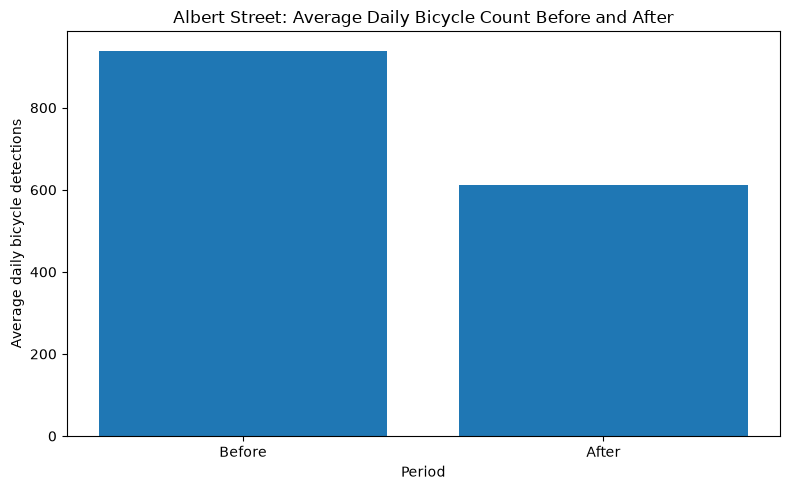

Saved: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\preliminary_before_after_eda\albert_preliminary_before_after_bar_chart.png


In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["PERIOD"].astype(str),
    comparison["AVERAGE_DAILY_COUNT"]
)

plt.title(
    "Albert Street: Average Daily Bicycle Count Before and After"
)
plt.xlabel("Period")
plt.ylabel("Average daily bicycle detections")
plt.tight_layout()

bar_chart_path = OUTPUT_DIR / "albert_preliminary_before_after_bar_chart.png"
plt.savefig(bar_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", bar_chart_path)


## 8. Supporting EDA — monthly trend and collection gap

In [10]:
monthly = (
    analysis_data
    .set_index("DATE_PARSED")
    .groupby("PERIOD")["BICYCLE_DETECTIONS"]
    .resample("MS")
    .mean()
    .rename("AVERAGE_DAILY_COUNT")
    .reset_index()
)

monthly.head()


,PERIOD,DATE_PARSED,AVERAGE_DAILY_COUNT
0,After,2020-06-01,480.884615
1,After,2020-07-01,417.129032
2,After,2020-08-01,303.935484
3,After,2020-09-01,360.200000
4,After,2020-10-01,449.806452


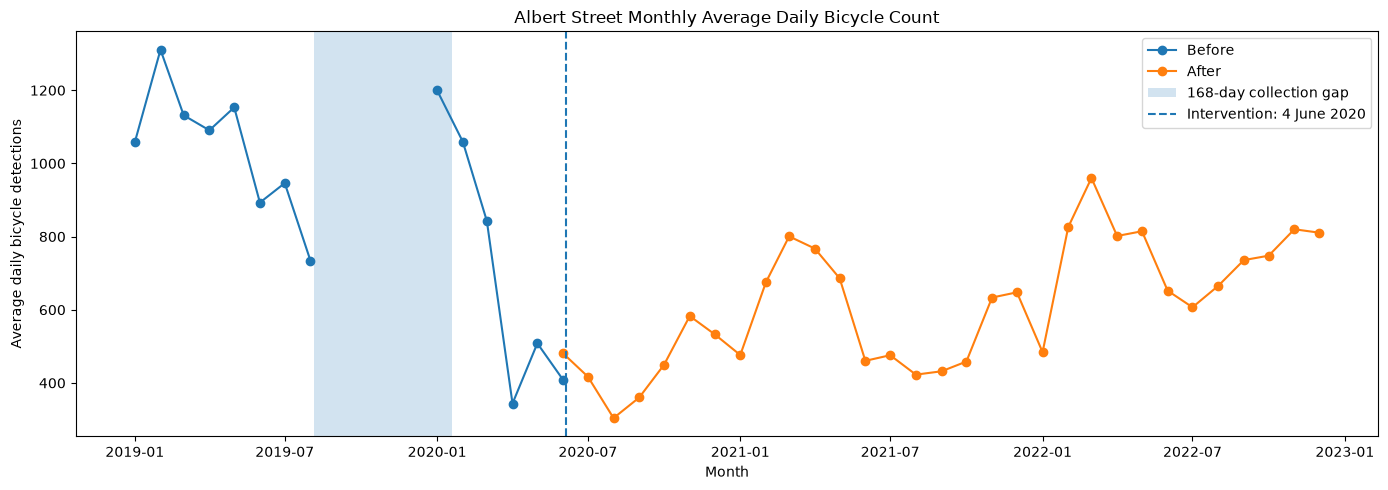

Saved: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\preliminary_before_after_eda\albert_preliminary_monthly_average_chart.png


In [11]:
plt.figure(figsize=(14, 5))

for period in ["Before", "After"]:
    group = monthly.loc[monthly["PERIOD"] == period]

    plt.plot(
        group["DATE_PARSED"],
        group["AVERAGE_DAILY_COUNT"],
        marker="o",
        label=period
    )

plt.axvspan(
    pd.Timestamp("2019-08-05"),
    pd.Timestamp("2020-01-19"),
    alpha=0.2,
    label="168-day collection gap"
)

plt.axvline(
    INTERVENTION_DATE,
    linestyle="--",
    label="Intervention: 4 June 2020"
)

plt.title("Albert Street Monthly Average Daily Bicycle Count")
plt.xlabel("Month")
plt.ylabel("Average daily bicycle detections")
plt.legend()
plt.tight_layout()

monthly_chart_path = OUTPUT_DIR / "albert_preliminary_monthly_average_chart.png"
plt.savefig(monthly_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", monthly_chart_path)


## 9. Supporting EDA — daily time series

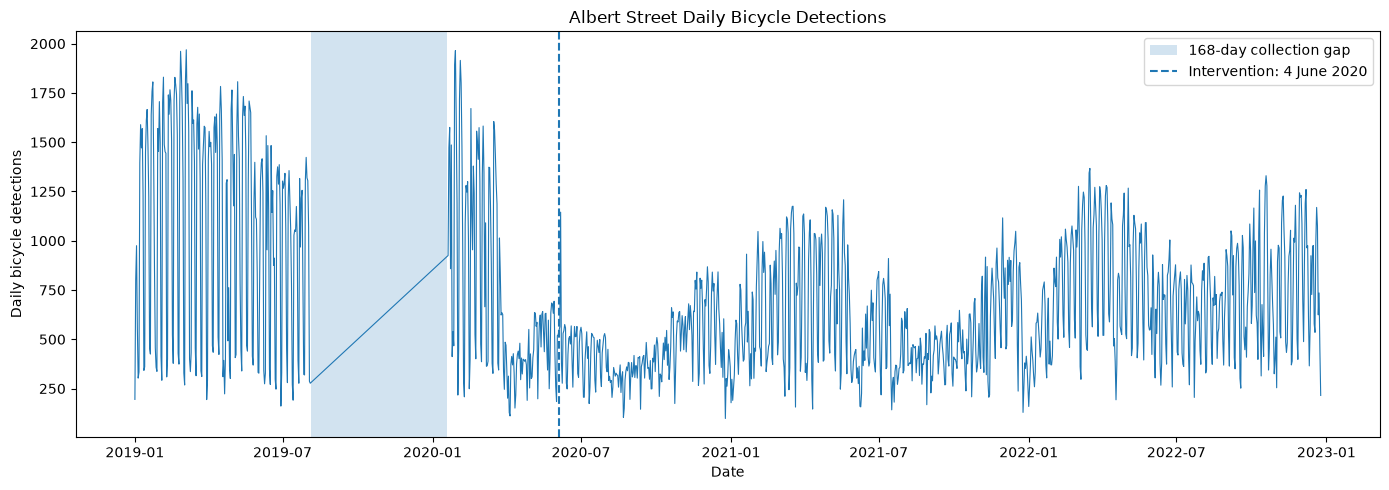

Saved: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\preliminary_before_after_eda\albert_preliminary_daily_time_series.png


In [12]:
plt.figure(figsize=(14, 5))

plt.plot(
    analysis_data["DATE_PARSED"],
    analysis_data["BICYCLE_DETECTIONS"],
    linewidth=0.8
)

plt.axvspan(
    pd.Timestamp("2019-08-05"),
    pd.Timestamp("2020-01-19"),
    alpha=0.2,
    label="168-day collection gap"
)

plt.axvline(
    INTERVENTION_DATE,
    linestyle="--",
    label="Intervention: 4 June 2020"
)

plt.title("Albert Street Daily Bicycle Detections")
plt.xlabel("Date")
plt.ylabel("Daily bicycle detections")
plt.legend()
plt.tight_layout()

daily_chart_path = OUTPUT_DIR / "albert_preliminary_daily_time_series.png"
plt.savefig(daily_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", daily_chart_path)


## 10. Data-quality context — collection-gap table

In [13]:
albert_gaps


,SITE_ID,STREET,GAP_START,GAP_END,GAP_DAYS
0,9077,Albert Street,2019-08-05,2020-01-19,168
1,9077,Albert Street,2022-12-26,2022-12-31,6


## 11. Export preliminary EDA outputs

In [14]:
comparison.to_csv(
    OUTPUT_DIR / "albert_preliminary_period_comparison.csv",
    index=False
)

summary.to_csv(
    OUTPUT_DIR / "albert_preliminary_before_after_summary.csv",
    index=False
)

analysis_data.to_csv(
    OUTPUT_DIR / "albert_preliminary_observed_days_with_period.csv",
    index=False
)

albert_gaps.to_csv(
    OUTPUT_DIR / "albert_preliminary_collection_gaps.csv",
    index=False
)

monthly.to_csv(
    OUTPUT_DIR / "albert_preliminary_monthly_average.csv",
    index=False
)

print("All outputs saved to:", OUTPUT_DIR)


All outputs saved to: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\preliminary_before_after_eda


## 12. Preliminary interpretation

This analysis uses **exact-duplicate-cleaned raw records** and only days with recorded bicycle observations. Missing dates are not imputed and are not treated as zero.

The duplicate sensitivity analysis in Notebook **03** showed that exact duplicate removal had a negligible effect on the before-and-after result. Using the cleaned data, the previously observed averages were approximately:

- **Before intervention:** 939.33 bicycle detections per observed day
- **After intervention:** 610.96 bicycle detections per observed day
- **Preliminary percentage change:** approximately **-34.96%**

The result should be interpreted cautiously. The before-intervention period contains a substantial **168-day collection gap from 5 August 2019 to 19 January 2020**. A further **6-day gap from 26 to 31 December 2022** occurs at the end of the study period.

Seasonal variation, COVID-19 disruptions, and other external influences may also affect cycling volumes. Therefore, this notebook provides **preliminary exploratory evidence only** and does not establish that the intervention caused the observed change.